# Advanced Optimization Problems with Generative Models

This notebook extends the basic examples to more challenging and interesting optimization problems.

## Table of Contents

1. [Setup](#setup)
2. [Multi-modal Optimization (Rastrigin)](#multimodal)
3. [Multi-objective / Pareto Front](#pareto)
4. [Inverse Design (Alloy Properties)](#inverse-design)
5. [PDE-Constrained Optimization (Heat Equation)](#pde)
6. [Trajectory Optimization / Optimal Control](#trajectory)
7. [Robust Optimization Under Uncertainty](#robust)
8. [Facility Location Problem](#facility)
9. [Equation of State Fitting](#eos)

---
<a id='setup'></a>
## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import warnings
import os

# Force CPU for JAX
os.environ['JAX_PLATFORMS'] = 'cpu'

import torch
from scipy.integrate import solve_ivp, odeint
from scipy.optimize import minimize
from scipy.interpolate import interp1d
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

# Import reusable utilities from local module
from generative_optimization import (
    generate_samples,
    best_gmm,
    cluster_stats,
    ConditionalFlowMatching,
    VelocityNetwork
)

# Force CPU for PyTorch
device = torch.device('cpu')
print(f"Using device: {device}")

# Figure settings
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


In [2]:
# Utility functions and classes are now imported from generative_optimization module:
# - generate_samples(): sampling utilities
# - best_gmm(): GMM model selection with BIC
# - cluster_stats(): cluster analysis
# - ConditionalFlowMatching: flow matching for inverse design
# - VelocityNetwork: neural network for velocity field prediction

---
<a id='multimodal'></a>
## 2. Multi-modal Optimization (Rastrigin Function)

The Rastrigin function has many local minima but a known global minimum at the origin:

$$f(\mathbf{x}) = 10n + \sum_{i=1}^{n} \left[ x_i^2 - 10\cos(2\pi x_i) \right]$$

We'll show how generative models can find multiple local minima by conditioning on gradient = 0.

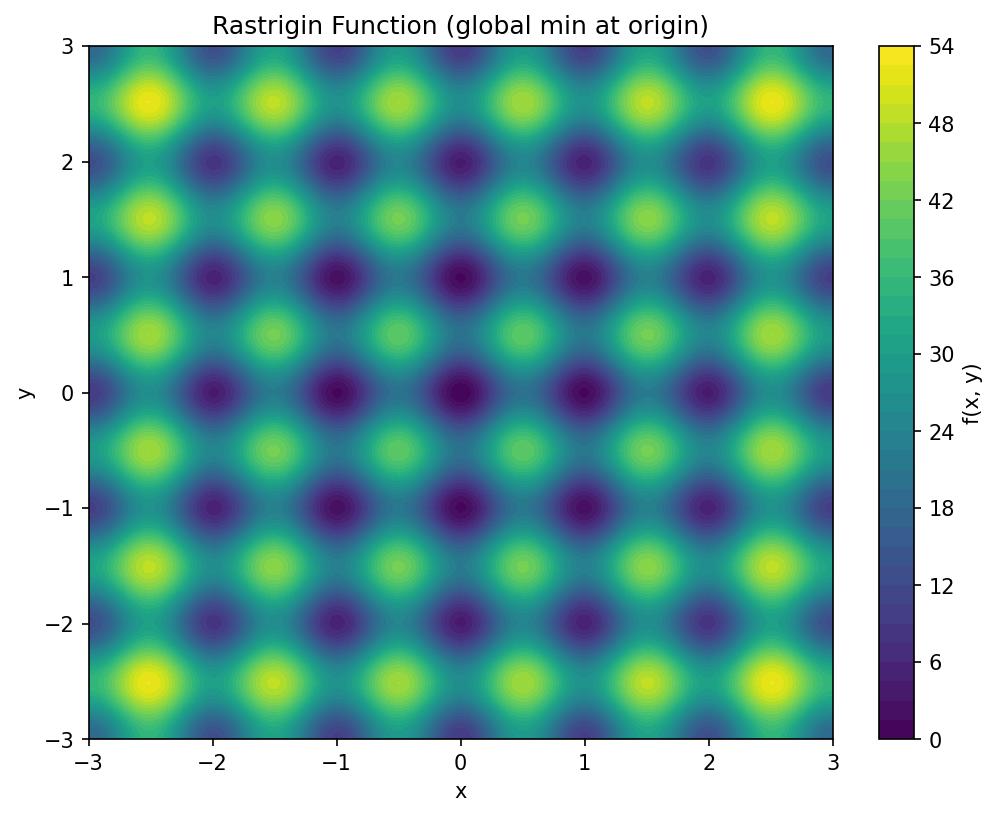

In [3]:
# Rastrigin function (2D)
def rastrigin(X):
    x, y = X[:, 0], X[:, 1]
    return 10*2 + (x**2 - 10*np.cos(2*np.pi*x)) + (y**2 - 10*np.cos(2*np.pi*y))

def rastrigin_grad(X):
    x, y = X[:, 0], X[:, 1]
    df_dx = 2*x + 20*np.pi*np.sin(2*np.pi*x)
    df_dy = 2*y + 20*np.pi*np.sin(2*np.pi*y)
    return np.column_stack([df_dx, df_dy])

# Visualize
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = rastrigin(np.column_stack([X.ravel(), Y.ravel()])).reshape(X.shape)

fig, ax = plt.subplots(figsize=(8, 6))
c = ax.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(c, label='f(x, y)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Rastrigin Function (global min at origin)')
plt.show()

In [4]:
# Generate training data with oversampling near stationary points
# Stationary points of Rastrigin occur at integer values of x and y
bounds = [[-3, 3], [-3, 3]]

# Base samples
base_samples = generate_samples(bounds, n_samples=2048, seed=42)

# Stationary points (integer grid points where gradient is exactly 0)
stationary_pts = []
for i in range(-3, 4):
    for j in range(-3, 4):
        stationary_pts.append([i, j])
stationary_pts = np.array(stationary_pts)

# Add the actual stationary points many times (they have gradient=0)
# This helps the model learn the exact mapping
exact_stationary = np.tile(stationary_pts, (100, 1))  # 100 copies each

# Add samples near each stationary point with small noise
near_stationary = []
rng = np.random.default_rng(42)
for pt in stationary_pts:
    # Add points very close to each stationary point
    noise = rng.normal(0, 0.1, (50, 2))
    near_pts = pt + noise
    # Keep only points within bounds
    mask = (near_pts[:, 0] >= -3) & (near_pts[:, 0] <= 3) & \
           (near_pts[:, 1] >= -3) & (near_pts[:, 1] <= 3)
    near_stationary.append(near_pts[mask])

near_stationary = np.vstack(near_stationary)
samples = np.vstack([base_samples, exact_stationary, near_stationary])

# Compute function values and gradients
f_values = rastrigin(samples)
gradients = rastrigin_grad(samples)

# Data for flow matching: x is position [x, y], c is gradient [df/dx, df/dy]
x_data = samples  # positions
c_data = gradients  # gradients as conditioning

print(f"Total samples: {len(samples)}")
print(f"  Base samples: {len(base_samples)}")
print(f"  Exact stationary points (repeated): {len(exact_stationary)}")
print(f"  Near stationary: {len(near_stationary)}")
print(f"Gradient magnitude range: [{np.linalg.norm(gradients, axis=1).min():.6f}, {np.linalg.norm(gradients, axis=1).max():.2f}]")
print(f"Number of exact zero gradients: {np.sum(np.linalg.norm(gradients, axis=1) < 1e-10)}")

Total samples: 8759
  Base samples: 2048
  Exact stationary points (repeated): 4900
  Near stationary: 1811
Gradient magnitude range: [0.000000, 94.47]
Number of exact zero gradients: 100


In [5]:
# Train Conditional Flow Matching to generate positions conditioned on gradients
fm_rast = ConditionalFlowMatching(x_dim=2, c_dim=2, hidden_dim=128, n_layers=4, sigma_min=0.001)
losses = fm_rast.fit(x_data, c_data, epochs=1000, batch_size=128, lr=1e-3)

# Sample stationary points by conditioning on gradient near 0
# Use multiple small perturbations to explore different modes
all_samples = []
n_conditions = 50
np.random.seed(42)

# Sample with exact gradient=0
samples_exact = fm_rast.sample(c_values=[[0.0, 0.0]], n_samples=500, n_steps=100)
all_samples.append(samples_exact)

# Sample with small perturbations to find nearby stationary points
for _ in range(n_conditions - 1):
    grad_condition = np.random.randn(2) * 2  # Small random gradient
    samples = fm_rast.sample(c_values=[grad_condition], n_samples=30, n_steps=100)
    all_samples.append(samples)

stationary_samples = np.vstack(all_samples)

# Evaluate function and gradient at sampled points
f_at_samples = rastrigin(stationary_samples)
grad_at_samples = rastrigin_grad(stationary_samples)
grad_norm = np.linalg.norm(grad_at_samples, axis=1)

print(f"Found {len(stationary_samples)} candidate stationary points")
print(f"Function values range: [{f_at_samples.min():.2f}, {f_at_samples.max():.2f}]")
print(f"Gradient norm: mean={grad_norm.mean():.4f}, max={grad_norm.max():.4f}")

Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Found 1970 candidate stationary points
Function values range: [0.00, 42.99]
Gradient norm: mean=45.7122, max=91.8298


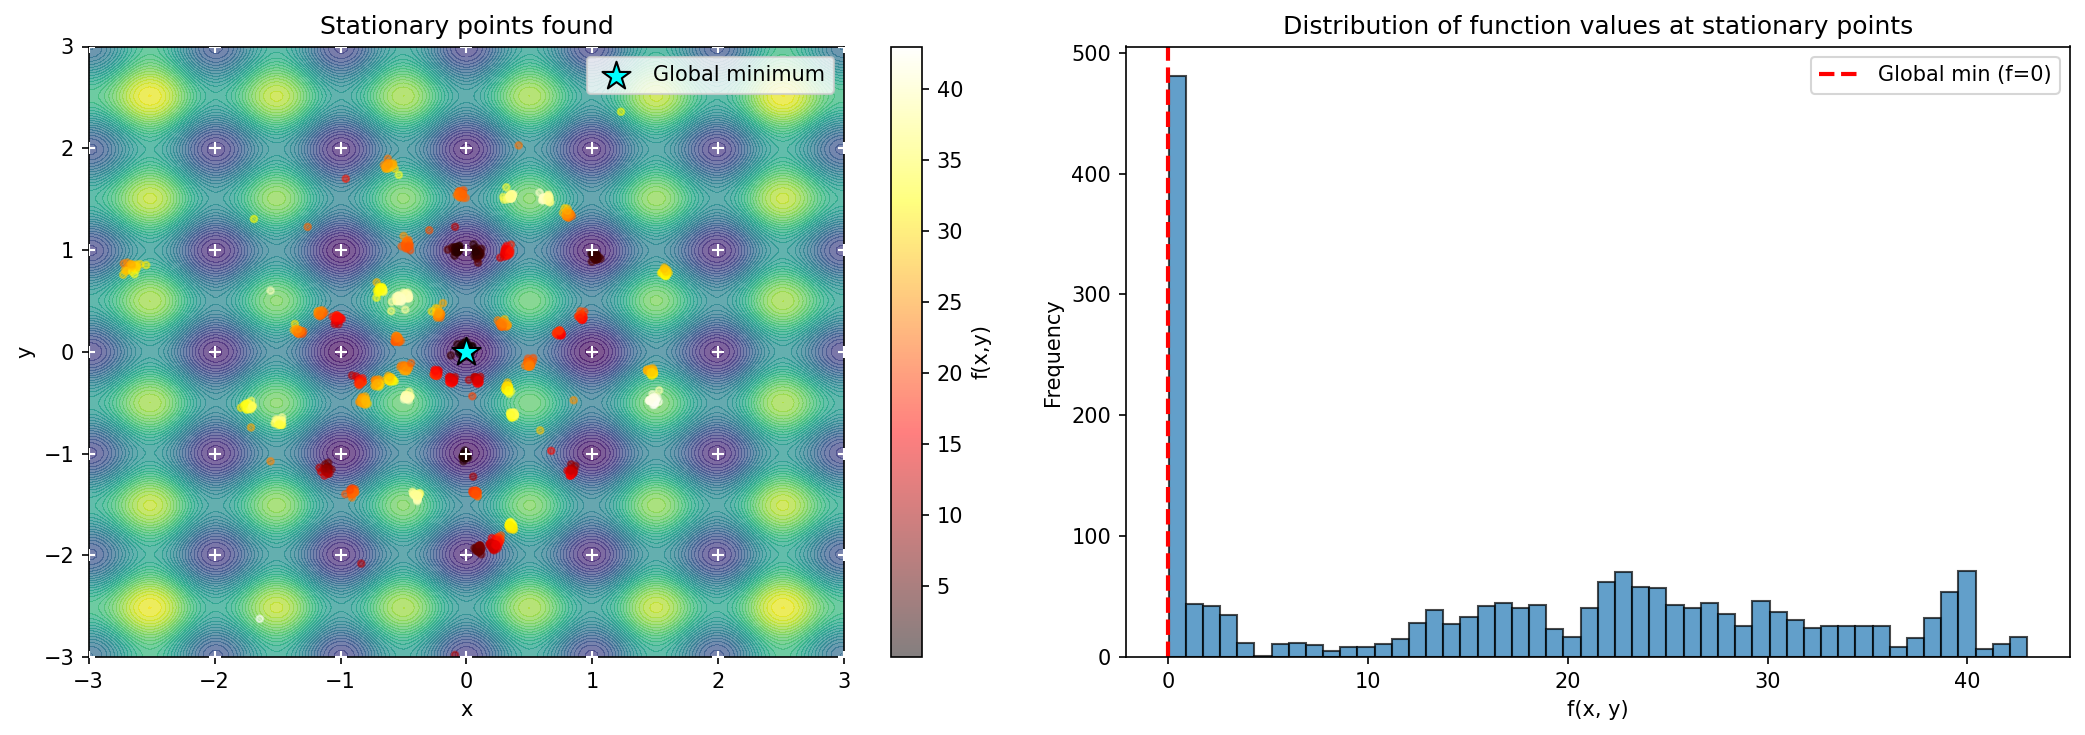


Cluster analysis of found stationary points:
 -1: mean=[-0.6444557  -0.00146811], std=[1.0192313 1.849316 ] (n=11)
  0: mean=[-0.07149402 -0.04889009], std=[0.4184964  0.33023492] (n=1127)
  1: mean=[0.1988491 1.242814 ], std=[0.38263196 0.2494313 ] (n=237)
  2: mean=[1.5778172  0.77678853], std=[0.01301432 0.019926  ] (n=30)
  3: mean=[ 0.22928186 -1.8521496 ], std=[0.09219559 0.08827535] (n=120)
  4: mean=[-1.6088923 -0.6178042], std=[0.12330008 0.08273078] (n=59)
  5: mean=[-1.1753563   0.30079502], std=[0.12914264 0.07503726] (n=88)
  6: mean=[-1.0097824 -1.2683303], std=[0.10378741 0.11078259] (n=60)
  7: mean=[ 1.4787652  -0.33415464], std=[0.01907794 0.1389725 ] (n=59)
  8: mean=[ 0.03005644 -1.2026346 ], std=[0.04305694 0.17917445] (n=60)
  9: mean=[-0.613838   1.8256549], std=[0.02444326 0.02623975] (n=30)
 10: mean=[1.0236477  0.93212813], std=[0.01509022 0.01974816] (n=30)
 11: mean=[-2.6551852   0.83031976], std=[0.0391347  0.02944413] (n=29)
 12: mean=[-0.39417368 -1.4155

TypeError: object of type 'NoneType' has no len()

In [6]:
# Visualize found stationary points
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter on contour
axes[0].contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
scatter = axes[0].scatter(stationary_samples[:, 0], stationary_samples[:, 1], 
                          c=f_at_samples, cmap='hot', s=10, alpha=0.5)
axes[0].scatter([0], [0], c='cyan', s=200, marker='*', edgecolors='black',
                label='Global minimum', zorder=5)
# Mark true stationary points
for pt in stationary_pts:
    axes[0].scatter(pt[0], pt[1], c='white', s=30, marker='+', linewidths=1, zorder=4)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Stationary points found')
axes[0].legend()
plt.colorbar(scatter, ax=axes[0], label='f(x,y)')

# Right: histogram of function values
axes[1].hist(f_at_samples, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='r', ls='--', lw=2, label='Global min (f=0)')
axes[1].set_xlabel('f(x, y)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of function values at stationary points')
axes[1].legend()

plt.tight_layout()
plt.show()

# Cluster analysis
print("\nCluster analysis of found stationary points:")
stats = cluster_stats(stationary_samples, eps=0.3, min_samples=10)
print(f"\nFound {len(stats)} clusters (true stationary points: {len(stationary_pts)})")

In [ ]:
# Filter samples to find points near the global minimum
# The global minimum is at (0, 0) with f(0,0) = 0
# Filter for samples with small f values
near_global = stationary_samples[f_at_samples < 1.0]

print("Samples near global minimum (f < 1.0):")
print(f"  Count: {len(near_global)}")
if len(near_global) > 0:
    print(f"  Mean position: {near_global.mean(axis=0)}")
    print(f"  Std position: {near_global.std(axis=0)}")
    print(f"  True global min: [0, 0]")
    
# Also show samples at local minima (f values around 1, 2, etc.)
print("\nSamples at different f value ranges:")
for f_lo, f_hi in [(0, 1), (0.5, 1.5), (1.5, 2.5), (3.5, 4.5)]:
    mask = (f_at_samples >= f_lo) & (f_at_samples < f_hi)
    if mask.sum() > 0:
        print(f"  f in [{f_lo}, {f_hi}): {mask.sum()} samples")

---
<a id='pareto'></a>
## 3. Multi-objective Optimization / Pareto Front

**ZDT1** is a standard benchmark problem for multi-objective optimization, named after its creators Zitzler, Deb, and Thiele (2000).

### Mathematical Definition

For a decision vector **x** = (x₁, x₂, ..., xₙ) where xᵢ ∈ [0, 1]:

**Objective 1:** $f_1(x) = x_1$

**Objective 2:** $f_2(x) = g(x) \cdot h(f_1, g)$

where:
$$g(x) = 1 + \frac{9}{n-1} \sum_{i=2}^{n} x_i$$
$$h(f_1, g) = 1 - \sqrt{\frac{f_1}{g}}$$

### Key Properties

| Property | Value |
|----------|-------|
| Decision variables | n (we use 3 for simplicity) |
| Objectives | 2 (minimize both f₁ and f₂) |
| Domain | [0, 1]ⁿ |
| Pareto front | Convex |
| Optimal condition | x₂ = x₃ = ... = xₙ = 0 |

### Pareto Front

The true Pareto front occurs when g(x) = 1 (all variables except x₁ are zero):
$$f_2 = 1 - \sqrt{f_1}$$

This gives a convex front from (0, 1) to (1, 0).

### Why ZDT1 is Used

ZDT1 tests an algorithm's ability to:
- Find the full Pareto front (not just endpoints)
- Maintain diversity along the front
- Converge to the true optimal front
- Handle many decision variables (scalable difficulty)

**References:**
- Zitzler, E., Deb, K., & Thiele, L. (2000). Comparison of multiobjective evolutionary algorithms: Empirical results. *Evolutionary Computation*, 8(2), 173-195.
- Huband, S., Hingston, P., Barone, L., & While, L. (2006). A review of multiobjective test problems and a scalable test problem toolkit. *IEEE Transactions on Evolutionary Computation*, 10(5), 477-506.

In [ ]:
# ZDT1 problem (3 decision variables for simplicity)
def zdt1(X):
    """ZDT1 multi-objective function."""
    n = X.shape[1]
    f1 = X[:, 0]
    g = 1 + 9 * X[:, 1:].sum(axis=1) / (n - 1)
    h = 1 - np.sqrt(f1 / g)
    f2 = g * h
    return np.column_stack([f1, f2])

# Generate data
n_vars = 3
bounds = [[0, 1]] * n_vars
X = generate_samples(bounds, n_samples=2048, seed=42)

# Compute objectives
F = zdt1(X)

# Data: [x1, x2, x3, f1, f2]
data = np.column_stack([X, F])
print(f"Data shape: {data.shape}")

In [ ]:
# Visualize objective space
plt.figure(figsize=(8, 6))
plt.scatter(F[:, 0], F[:, 1], c='blue', s=5, alpha=0.3, label='Sampled points')

# True Pareto front
f1_true = np.linspace(0, 1, 100)
f2_true = 1 - np.sqrt(f1_true)
plt.plot(f1_true, f2_true, 'r-', lw=2, label='True Pareto front')

plt.xlabel('$f_1$')
plt.ylabel('$f_2$')
plt.title('ZDT1 Objective Space')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Build GMM: generate x given desired (f1, f2) on Pareto front
gmm_pareto = best_gmm(data)

# Sample points along the Pareto front
f1_targets = np.linspace(0.1, 0.9, 9)
f2_targets = 1 - np.sqrt(f1_targets)

pareto_solutions = []
for f1, f2 in zip(f1_targets, f2_targets):
    # Condition on desired objectives
    pred = gmm_pareto.predict([3, 4], np.array([[f1, f2]]))
    pareto_solutions.append(pred[0])

pareto_solutions = np.array(pareto_solutions)
print(f"Generated {len(pareto_solutions)} Pareto-optimal solutions")

In [ ]:
# Verify: compute objectives for generated solutions
F_generated = zdt1(pareto_solutions)

plt.figure(figsize=(8, 6))
plt.scatter(F[:, 0], F[:, 1], c='lightblue', s=5, alpha=0.3, label='All samples')
plt.plot(f1_true, f2_true, 'r-', lw=2, label='True Pareto front')
plt.scatter(F_generated[:, 0], F_generated[:, 1], c='green', s=100, marker='o',
            edgecolors='black', label='Generated Pareto solutions', zorder=5)

# Show target points
plt.scatter(f1_targets, f2_targets, c='red', s=50, marker='x', 
            label='Target objectives', zorder=6)

plt.xlabel('$f_1$')
plt.ylabel('$f_2$')
plt.title('Generative Pareto Front Discovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print errors
print("\nTarget vs Achieved objectives:")
for i, (f1_t, f2_t) in enumerate(zip(f1_targets, f2_targets)):
    f1_a, f2_a = F_generated[i]
    print(f"  Target: ({f1_t:.2f}, {f2_t:.2f}) -> Achieved: ({f1_a:.3f}, {f2_a:.3f})")

In [ ]:
# Visualize decision variables along Pareto front
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].plot(f1_targets, pareto_solutions[:, i], 'o-')
    axes[i].set_xlabel('$f_1$ (target)')
    axes[i].set_ylabel(f'$x_{i+1}$')
    axes[i].set_title(f'Decision variable $x_{i+1}$')
    axes[i].grid(True, alpha=0.3)
    
    # For ZDT1, optimal solution has x2=x3=...=0
    if i > 0:
        axes[i].axhline(0, color='r', ls='--', label='Optimal')
        axes[i].legend()

plt.tight_layout()
plt.show()

---
<a id='inverse-design'></a>
## 4. Inverse Design: Alloy Properties

Given desired material properties (e.g., yield strength, melting point), find the alloy composition.

We'll use a simplified model where properties depend on composition.

In [ ]:
# Simplified alloy model: 3 components (e.g., Fe, Ni, Cr) with compositions summing to 1
# Properties are synthetic functions of composition

def alloy_properties(comp):
    """Compute yield strength and melting point from composition.
    
    comp: [Fe, Ni, Cr] fractions (sum to ~1)
    Returns: [yield_strength (MPa), melting_point (K)]
    """
    Fe, Ni, Cr = comp[:, 0], comp[:, 1], comp[:, 2]
    
    # Synthetic property models (inspired by real metallurgy)
    # Yield strength: Ni strengthens, Cr has modest effect
    yield_strength = 200 + 400*Ni + 150*Cr + 100*Fe*Ni + 50*Ni*Cr
    
    # Melting point: Fe-based, Ni lowers slightly, Cr raises
    melting_point = 1800 - 50*Ni + 100*Cr + 20*Fe*Cr
    
    return np.column_stack([yield_strength, melting_point])

# Generate composition samples (on simplex: sum to 1)
n_samples = 2000
rng = np.random.default_rng(42)
# Dirichlet sampling for compositions
compositions = rng.dirichlet([1, 1, 1], size=n_samples)

# Compute properties
properties = alloy_properties(compositions)

print(f"Compositions shape: {compositions.shape}")
print(f"Properties shape: {properties.shape}")
print(f"Yield strength range: [{properties[:, 0].min():.0f}, {properties[:, 0].max():.0f}] MPa")
print(f"Melting point range: [{properties[:, 1].min():.0f}, {properties[:, 1].max():.0f}] K")

In [ ]:
# Visualize property space
plt.figure(figsize=(8, 6))
scatter = plt.scatter(properties[:, 0], properties[:, 1], 
                      c=compositions[:, 1], cmap='plasma', s=10, alpha=0.5)
plt.colorbar(scatter, label='Ni fraction')
plt.xlabel('Yield Strength (MPa)')
plt.ylabel('Melting Point (K)')
plt.title('Alloy Property Space')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Build GMM for inverse design
# Data: [Fe, Ni, Cr, yield_strength, melting_point]
data = np.column_stack([compositions, properties])

gmm_alloy = best_gmm(data)
print("GMM trained for inverse alloy design")

In [ ]:
# Inverse design: find composition for target properties
# Target: high yield strength (500 MPa), high melting point (1850 K)

target_properties = [
    [350, 1800],  # Moderate strength, moderate melting point
    [500, 1850],  # High strength, high melting point
    [250, 1900],  # Low strength, very high melting point
]

print("Inverse Design Results:")
print("="*60)

for target in target_properties:
    # Condition on properties, predict composition
    c = gmm_alloy.condition([3, 4], [target])
    samples = c.sample(500)
    
    # Get raw composition samples
    comp_samples = samples[:, :3]
    
    # Clip to valid range [0, 1] and normalize to sum to 1
    comp_samples = np.clip(comp_samples, 0, 1)
    comp_samples = comp_samples / comp_samples.sum(axis=1, keepdims=True)
    
    # Get mean composition (already normalized)
    comp_mean = comp_samples.mean(axis=0)
    comp_std = comp_samples.std(axis=0)
    
    # Verify by computing properties
    achieved = alloy_properties(comp_mean.reshape(1, -1))[0]
    
    print(f"\nTarget: Yield={target[0]} MPa, Tm={target[1]} K")
    print(f"  Composition: Fe={comp_mean[0]:.3f}, Ni={comp_mean[1]:.3f}, Cr={comp_mean[2]:.3f}")
    print(f"  Achieved:    Yield={achieved[0]:.0f} MPa, Tm={achieved[1]:.0f} K")
    
    # Check if target is achievable within the property space
    if achieved[0] < target[0] - 50 or achieved[1] < target[1] - 50:
        print(f"  Note: Target may be outside feasible property space")

In [ ]:
# Visualize composition uncertainty for one target
target = [350, 1800]  # Use a feasible target
c = gmm_alloy.condition([3, 4], [target])
samples = c.sample(1000)

# Clip and normalize compositions
comp_samples = samples[:, :3]
comp_samples = np.clip(comp_samples, 0, 1)
comp_samples = comp_samples / comp_samples.sum(axis=1, keepdims=True)

# Ternary-ish visualization (project to 2D)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

pairs = [(0, 1, 'Fe', 'Ni'), (1, 2, 'Ni', 'Cr'), (0, 2, 'Fe', 'Cr')]
for ax, (i, j, xi, xj) in zip(axes, pairs):
    ax.scatter(comp_samples[:, i], comp_samples[:, j], alpha=0.3, s=10)
    ax.set_xlabel(xi)
    ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Composition uncertainty for target (Yield={target[0]}, Tm={target[1]})')
plt.tight_layout()
plt.show()

---
<a id='pde'></a>
## 5. PDE-Constrained Optimization (Heat Equation)

**Inverse problem**: Given a desired steady-state temperature profile $T(x)$, find the heat source distribution $q(x)$.

The 1D steady-state heat equation: $-k \frac{d^2T}{dx^2} = q(x)$

With boundary conditions: $T(0) = T(1) = 0$

In [ ]:
# Discretize heat equation with finite differences
n_points = 20  # Interior points
dx = 1.0 / (n_points + 1)
x_grid = np.linspace(dx, 1 - dx, n_points)

def solve_heat_equation(q, k=1.0):
    """Solve -k*T'' = q with T(0)=T(1)=0.
    
    Returns temperature at interior points.
    """
    n = len(q)
    dx = 1.0 / (n + 1)
    
    # Build tridiagonal matrix for -T''
    diag = 2 * np.ones(n)
    off_diag = -1 * np.ones(n - 1)
    A = np.diag(diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    A = k * A / dx**2
    
    # Solve A*T = q
    T = np.linalg.solve(A, q)
    return T

# Generate training data: random heat sources and resulting temperatures
n_samples = 2000
rng = np.random.default_rng(42)

# Heat sources: smooth random functions (sum of sinusoids)
q_samples = []
T_samples = []

for _ in range(n_samples):
    # Random heat source (sum of low-frequency modes)
    coeffs = rng.normal(0, 1, 5)
    q = np.zeros(n_points)
    for i, c in enumerate(coeffs):
        q += c * np.sin((i + 1) * np.pi * x_grid)
    q = q * 10  # Scale
    
    # Solve for temperature
    T = solve_heat_equation(q)
    
    q_samples.append(q)
    T_samples.append(T)

q_samples = np.array(q_samples)
T_samples = np.array(T_samples)

print(f"Heat source samples: {q_samples.shape}")
print(f"Temperature samples: {T_samples.shape}")

In [ ]:
# Visualize some examples
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for i in range(3):
    axes[0, i].plot(x_grid, q_samples[i], 'b-')
    axes[0, i].set_ylabel('q(x)')
    axes[0, i].set_title(f'Heat source {i+1}')
    axes[0, i].grid(True, alpha=0.3)
    
    axes[1, i].plot(x_grid, T_samples[i], 'r-')
    axes[1, i].set_xlabel('x')
    axes[1, i].set_ylabel('T(x)')
    axes[1, i].set_title(f'Temperature {i+1}')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Reduce dimensionality using PCA for GMM
from sklearn.decomposition import PCA

n_components = 5  # Number of modes to keep

pca_q = PCA(n_components=n_components)
pca_T = PCA(n_components=n_components)

q_reduced = pca_q.fit_transform(q_samples)
T_reduced = pca_T.fit_transform(T_samples)

print(f"Explained variance (q): {pca_q.explained_variance_ratio_.sum():.3f}")
print(f"Explained variance (T): {pca_T.explained_variance_ratio_.sum():.3f}")

In [ ]:
# Build GMM in reduced space
# Data: [q_modes, T_modes]
data_pde = np.column_stack([q_reduced, T_reduced])
gmm_heat = best_gmm(data_pde)
print("GMM trained for heat equation inverse problem")

In [ ]:
# Inverse problem: given target temperature, find heat source
# Target: parabolic temperature profile (maximum at center)
T_target = 4 * x_grid * (1 - x_grid)  # Parabola with max at x=0.5
T_target = T_target * 5  # Scale

# Project to reduced space
T_target_reduced = pca_T.transform(T_target.reshape(1, -1))

# Condition on temperature, generate heat source
T_cols = list(range(n_components, 2*n_components))
pred = gmm_heat.predict(T_cols, T_target_reduced)

# Reconstruct heat source
q_pred = pca_q.inverse_transform(pred.reshape(1, -1))[0]

# Verify by solving forward problem
T_achieved = solve_heat_equation(q_pred)

In [ ]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x_grid, q_pred, 'b-', lw=2, label='Predicted q(x)')
# Analytical solution for parabolic T: q = 8 (constant)
axes[0].axhline(8*5, color='r', ls='--', label='Analytical q = 40')
axes[0].set_xlabel('x')
axes[0].set_ylabel('q(x)')
axes[0].set_title('Heat Source (Inverse Solution)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid, T_target, 'r-', lw=2, label='Target T(x)')
axes[1].plot(x_grid, T_achieved, 'b--', lw=2, label='Achieved T(x)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('T(x)')
axes[1].set_title('Temperature Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error
mae = np.mean(np.abs(T_target - T_achieved))
print(f"Temperature MAE: {mae:.4f}")

---
<a id='trajectory'></a>
## 6. Trajectory Optimization / Optimal Control

Find control inputs $u(t)$ that drive a system from initial state to target final state.

**System**: Simple 1D dynamics $\ddot{x} = u$ (double integrator)

**Goal**: Drive from $(x_0, v_0) = (0, 0)$ to $(x_f, v_f)$ in fixed time $T$.

In [ ]:
# Double integrator dynamics
# State: [x, v], Control: u
# dx/dt = v, dv/dt = u

T_final = 1.0  # Final time
n_control_points = 10  # Parameterize control with spline control points
t_control = np.linspace(0, T_final, n_control_points)

def simulate_trajectory(u_points, x0=0, v0=0):
    """Simulate trajectory given control point values."""
    # Interpolate control
    u_interp = interp1d(t_control, u_points, kind='cubic', fill_value='extrapolate')
    
    def dynamics(t, state):
        x, v = state
        u = u_interp(t)
        return [v, u]
    
    # Simulate
    t_eval = np.linspace(0, T_final, 50)
    sol = solve_ivp(dynamics, [0, T_final], [x0, v0], t_eval=t_eval)
    
    return sol.t, sol.y[0], sol.y[1]  # t, x, v

# Generate training data: random control inputs and resulting final states
n_samples = 2000
rng = np.random.default_rng(42)

u_samples = []
final_states = []

for _ in range(n_samples):
    # Random smooth control (bounded)
    u_points = rng.uniform(-5, 5, n_control_points)
    # Smooth by averaging neighbors
    u_points = np.convolve(u_points, [0.25, 0.5, 0.25], mode='same')
    
    # Simulate
    t, x, v = simulate_trajectory(u_points)
    
    u_samples.append(u_points)
    final_states.append([x[-1], v[-1]])

u_samples = np.array(u_samples)
final_states = np.array(final_states)

print(f"Control samples: {u_samples.shape}")
print(f"Final states: {final_states.shape}")
print(f"Final position range: [{final_states[:, 0].min():.2f}, {final_states[:, 0].max():.2f}]")
print(f"Final velocity range: [{final_states[:, 1].min():.2f}, {final_states[:, 1].max():.2f}]")

In [ ]:
# Visualize reachable set
plt.figure(figsize=(8, 6))
plt.scatter(final_states[:, 0], final_states[:, 1], c='blue', s=5, alpha=0.3)
plt.xlabel('Final position $x_f$')
plt.ylabel('Final velocity $v_f$')
plt.title('Reachable Final States')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [ ]:
# Build GMM: generate control given desired final state
data_traj = np.column_stack([u_samples, final_states])
gmm_traj = best_gmm(data_traj)
print("GMM trained for trajectory optimization")

In [ ]:
# Inverse problem: find control for desired final state
targets = [
    [1.0, 0.0],   # Move to x=1, stop
    [0.5, 1.0],   # Move to x=0.5 with velocity 1
    [-0.5, 0.5],  # Move backward with positive velocity
]

fig, axes = plt.subplots(len(targets), 3, figsize=(14, 4*len(targets)))

for i, target in enumerate(targets):
    # Condition on final state, predict control points
    # Data columns: [u0, u1, ..., u9, x_final, v_final]
    # Condition on columns [10, 11] (final state), predict columns [0-9] (control)
    final_cols = [n_control_points, n_control_points + 1]
    pred = gmm_traj.predict(final_cols, np.array([target]))
    # pred has shape (1, n_control_points) - extract the single row
    u_pred = pred[0]
    
    # Simulate
    t, x, v = simulate_trajectory(u_pred)
    
    # Plot control
    axes[i, 0].plot(t_control, u_pred, 'bo-', label='Control points')
    u_interp = interp1d(t_control, u_pred, kind='cubic')
    t_fine = np.linspace(0, T_final, 100)
    axes[i, 0].plot(t_fine, u_interp(t_fine), 'b-', alpha=0.5)
    axes[i, 0].set_xlabel('Time')
    axes[i, 0].set_ylabel('Control u(t)')
    axes[i, 0].set_title(f'Control for target ({target[0]}, {target[1]})')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Plot position
    axes[i, 1].plot(t, x, 'g-', lw=2)
    axes[i, 1].axhline(target[0], color='r', ls='--', label=f'Target x={target[0]}')
    axes[i, 1].set_xlabel('Time')
    axes[i, 1].set_ylabel('Position x(t)')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)
    
    # Plot velocity
    axes[i, 2].plot(t, v, 'm-', lw=2)
    axes[i, 2].axhline(target[1], color='r', ls='--', label=f'Target v={target[1]}')
    axes[i, 2].set_xlabel('Time')
    axes[i, 2].set_ylabel('Velocity v(t)')
    axes[i, 2].legend()
    axes[i, 2].grid(True, alpha=0.3)
    
    print(f"Target: x={target[0]}, v={target[1]} -> Achieved: x={x[-1]:.3f}, v={v[-1]:.3f}")

plt.tight_layout()
plt.show()

---
<a id='robust'></a>
## 7. Robust Optimization Under Uncertainty

Find solutions that perform well across uncertain parameters.

**Problem**: Design x to minimize worst-case cost over uncertain θ:
$$\min_x \max_\theta f(x, \theta)$$

We'll use a simple example where the objective depends on both design and uncertainty.

In [ ]:
# Robust optimization example
# f(x, θ) = (x - θ)² + 0.1*x²
# θ ∈ [-1, 1] is uncertain
# Optimal robust solution: x that minimizes max over θ

def objective(x, theta):
    return (x - theta)**2 + 0.1*x**2

def worst_case_cost(x, theta_range=[-1, 1]):
    """Compute worst-case (maximum) cost over theta range."""
    # For this simple problem, worst case is at boundary
    costs = [objective(x, theta_range[0]), objective(x, theta_range[1])]
    return max(costs)

# Generate data: sample (x, θ) and compute cost
n_samples = 5000
x_samples = np.random.uniform(-2, 2, n_samples)
theta_samples = np.random.uniform(-1, 1, n_samples)
costs = objective(x_samples, theta_samples)

# Also compute statistics over θ for each x
x_unique = np.linspace(-2, 2, 100)
theta_grid = np.linspace(-1, 1, 50)

mean_costs = []
max_costs = []
for x in x_unique:
    c = objective(x, theta_grid)
    mean_costs.append(c.mean())
    max_costs.append(c.max())

mean_costs = np.array(mean_costs)
max_costs = np.array(max_costs)

In [ ]:
# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: cost surface
X_grid, Theta_grid = np.meshgrid(x_unique, theta_grid)
Cost_grid = objective(X_grid, Theta_grid)
c = axes[0].contourf(X_grid, Theta_grid, Cost_grid, levels=30, cmap='viridis')
plt.colorbar(c, ax=axes[0], label='Cost')
axes[0].set_xlabel('Design x')
axes[0].set_ylabel('Uncertainty θ')
axes[0].set_title('Cost landscape $f(x, \\theta)$')

# Right: mean and worst-case cost vs x
axes[1].plot(x_unique, mean_costs, 'b-', lw=2, label='Mean cost')
axes[1].plot(x_unique, max_costs, 'r-', lw=2, label='Worst-case cost')

# Optimal points
x_opt_mean = x_unique[np.argmin(mean_costs)]
x_opt_robust = x_unique[np.argmin(max_costs)]
axes[1].axvline(x_opt_mean, color='b', ls='--', alpha=0.5, label=f'Optimal mean: x={x_opt_mean:.2f}')
axes[1].axvline(x_opt_robust, color='r', ls='--', alpha=0.5, label=f'Optimal robust: x={x_opt_robust:.2f}')

axes[1].set_xlabel('Design x')
axes[1].set_ylabel('Cost')
axes[1].set_title('Mean vs Worst-case Cost')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Build GMM for robust optimization
# Include worst-case cost in data
# For each sample, compute its worst-case cost
wc_costs = np.array([worst_case_cost(x) for x in x_samples])

# Data: [x, θ, cost, worst_case_cost]
data_robust = np.column_stack([x_samples, theta_samples, costs, wc_costs])

gmm_robust = best_gmm(data_robust)
print("GMM trained for robust optimization")

In [ ]:
# Find robust optimal design by conditioning on low worst-case cost
# Condition on worst_case_cost being low
target_wc = min_costs = np.percentile(wc_costs, 5)  # Target 5th percentile

c = gmm_robust.condition([3], [[target_wc]])
samples = c.sample(1000)

x_robust_samples = samples[:, 0]

print(f"Target worst-case cost: {target_wc:.3f}")
print(f"Robust design x: {x_robust_samples.mean():.3f} ± {x_robust_samples.std():.3f}")
print(f"Analytical optimal (for this problem): x ≈ 0")

In [ ]:
# Visualize
plt.figure(figsize=(8, 5))
plt.hist(x_robust_samples, bins=30, density=True, alpha=0.7, label='Robust samples')
plt.axvline(x_opt_robust, color='r', ls='--', lw=2, label=f'True optimal: {x_opt_robust:.2f}')
plt.axvline(x_robust_samples.mean(), color='g', ls='-', lw=2, label=f'GMM mean: {x_robust_samples.mean():.2f}')
plt.xlabel('Design x')
plt.ylabel('Density')
plt.title('Robust Optimal Design Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
<a id='facility'></a>
## 8. Facility Location Problem

Place N facilities to minimize total weighted distance to demand points.

**Continuous relaxation**: Facility locations are continuous variables.

In [ ]:
# Generate demand points
n_demand = 20
rng = np.random.default_rng(42)
demand_points = rng.uniform(0, 10, (n_demand, 2))
demand_weights = rng.uniform(0.5, 2, n_demand)

# Number of facilities to place
n_facilities = 3

def total_cost(facility_locations, demand_points, weights):
    """Compute total weighted distance to nearest facility."""
    facilities = facility_locations.reshape(-1, 2)
    total = 0
    for i, (dp, w) in enumerate(zip(demand_points, weights)):
        # Distance to each facility
        dists = np.sqrt(((facilities - dp)**2).sum(axis=1))
        total += w * dists.min()  # Distance to nearest
    return total

# Visualize demand points
plt.figure(figsize=(8, 8))
plt.scatter(demand_points[:, 0], demand_points[:, 1], 
            s=demand_weights*50, c='blue', alpha=0.6, label='Demand points')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Facility Location: {n_demand} demand points, {n_facilities} facilities')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Generate training data: random facility locations and resulting costs
# Use more samples and oversample low-cost configurations
n_samples = 10000

facility_samples = []
cost_samples = []

for _ in range(n_samples):
    # Random facility locations
    locs = rng.uniform(0, 10, n_facilities * 2)
    cost = total_cost(locs, demand_points, demand_weights)
    
    facility_samples.append(locs)
    cost_samples.append(cost)

facility_samples = np.array(facility_samples)
cost_samples = np.array(cost_samples)

# Oversample low-cost configurations by adding perturbed versions
threshold = np.percentile(cost_samples, 10)  # Top 10%
good_idx = cost_samples < threshold
good_samples = facility_samples[good_idx]
good_costs = cost_samples[good_idx]

print(f"Found {len(good_samples)} low-cost configurations (cost < {threshold:.2f})")

# Add perturbed versions of good solutions
oversampled = []
oversampled_costs = []
for locs in good_samples:
    for _ in range(20):  # 20 perturbations each
        noise = rng.normal(0, 0.3, n_facilities * 2)
        new_locs = np.clip(locs + noise, 0, 10)
        new_cost = total_cost(new_locs, demand_points, demand_weights)
        oversampled.append(new_locs)
        oversampled_costs.append(new_cost)

oversampled = np.array(oversampled)
oversampled_costs = np.array(oversampled_costs)

# Combine all data
all_facilities = np.vstack([facility_samples, oversampled])
all_costs = np.concatenate([cost_samples, oversampled_costs])

print(f"Total training samples: {len(all_facilities)}")
print(f"Cost range: [{all_costs.min():.2f}, {all_costs.max():.2f}]")

In [ ]:
# For this problem, we use a simpler approach:
# Sample from low-cost configurations directly, then refine
# (Flow matching struggles here because cost→locations is highly underdetermined)

# Sort by cost and take the best candidates
sort_idx = np.argsort(all_costs)
best_configs = all_facilities[sort_idx[:100]]  # Top 100 lowest cost
best_costs = all_costs[sort_idx[:100]]

print(f"Best 100 configurations have costs in range [{best_costs.min():.2f}, {best_costs.max():.2f}]")
print(f"Using direct sampling from low-cost region instead of flow matching")

In [ ]:
# Find optimal by selecting best sampled configuration and refining
# Pick the best from our sampled configurations
best_idx = np.argmin(best_costs)
sampled_locs = best_configs[best_idx].reshape(n_facilities, 2)
sampled_cost = best_costs[best_idx]

print(f"Best sampled configuration cost: {sampled_cost:.2f}")

# Refine with local optimization
result_refined = minimize(
    lambda x: total_cost(x, demand_points, demand_weights),
    x0=sampled_locs.flatten(),
    method='L-BFGS-B',
    bounds=[(0, 10)] * (n_facilities * 2)
)
refined_locs = result_refined.x.reshape(n_facilities, 2)
refined_cost = result_refined.fun

print(f"After local refinement cost: {refined_cost:.2f}")
print(f"Refined locations:\n{refined_locs}")

In [ ]:
# Compare with scipy optimizer
from scipy.optimize import minimize

result = minimize(
    lambda x: total_cost(x, demand_points, demand_weights),
    x0=rng.uniform(0, 10, n_facilities * 2),
    method='L-BFGS-B',
    bounds=[(0, 10)] * (n_facilities * 2)
)

scipy_locs = result.x.reshape(n_facilities, 2)
scipy_cost = result.fun

print(f"\nScipy optimization:")
print(f"  Cost: {scipy_cost:.2f}")
print(f"  Locations: {scipy_locs}")

In [ ]:
# Visualize solutions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

solutions = [
    (axes[0], sampled_locs, 'Best Sampled Configuration', sampled_cost),
    (axes[1], refined_locs, 'After Local Refinement', refined_cost),
    (axes[2], scipy_locs, 'Scipy (from random start)', scipy_cost)
]

for ax, locs, title, cost in solutions:
    ax.scatter(demand_points[:, 0], demand_points[:, 1], 
               s=demand_weights*50, c='blue', alpha=0.6, label='Demand')
    ax.scatter(locs[:, 0], locs[:, 1], 
               s=200, c='red', marker='*', edgecolors='black',
               label='Facilities', zorder=5)
    
    # Draw lines to nearest facility
    for dp in demand_points:
        dists = np.sqrt(((locs - dp)**2).sum(axis=1))
        nearest = locs[np.argmin(dists)]
        ax.plot([dp[0], nearest[0]], [dp[1], nearest[1]], 'g-', alpha=0.3)
    
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'{title}\n(Cost: {cost:.2f})')
    ax.legend()
    ax.set_xlim(-1, 11)
    ax.set_ylim(-1, 11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\nSummary:")
print(f"  Best sampled:         {sampled_cost:.2f}")
print(f"  After refinement:     {refined_cost:.2f}")
print(f"  Scipy (random start): {scipy_cost:.2f}")

---
<a id='eos'></a>
## 9. Equation of State Fitting

Fit van der Waals equation of state parameters from PVT data.

$$P = \frac{RT}{V - b} - \frac{a}{V^2}$$

Given experimental (P, V, T) data, find parameters (a, b).

In [ ]:
# Van der Waals equation
R = 8.314  # J/(mol·K)

def vdw_pressure(V, T, a, b):
    """Compute pressure from van der Waals equation."""
    return R * T / (V - b) - a / V**2

# True parameters (for CO2-like gas)
a_true = 0.364  # Pa·m⁶/mol²
b_true = 4.27e-5  # m³/mol

# Generate synthetic experimental data
n_data = 50
V_data = np.random.uniform(1e-4, 5e-4, n_data)  # m³/mol
T_data = np.random.uniform(300, 500, n_data)  # K
P_data = vdw_pressure(V_data, T_data, a_true, b_true)

# Add noise
P_data += np.random.normal(0, P_data * 0.02)  # 2% noise

print(f"True parameters: a = {a_true:.4f}, b = {b_true:.2e}")
print(f"P range: [{P_data.min()/1e6:.2f}, {P_data.max()/1e6:.2f}] MPa")

In [ ]:
# Generate training data: sample (a, b) and compute pressures
n_samples = 3000

# Sample parameters around reasonable range
a_samples = np.random.uniform(0.1, 0.8, n_samples)
b_samples = np.random.uniform(1e-5, 1e-4, n_samples)

# For each (a,b), compute pressure at several (V,T) points
# Use representative V, T values
V_repr = np.array([1.5e-4, 2.5e-4, 3.5e-4])  # 3 representative V values
T_repr = np.array([350, 400, 450])  # 3 representative T values

# Compute pressures for all combinations
P_samples = []
for a, b in zip(a_samples, b_samples):
    P_vals = []
    for V, T in zip(V_repr, T_repr):
        try:
            P = vdw_pressure(V, T, a, b)
            P_vals.append(P / 1e6)  # Convert to MPa
        except:
            P_vals.append(np.nan)
    P_samples.append(P_vals)

P_samples = np.array(P_samples)

# Remove invalid samples
valid = ~np.isnan(P_samples).any(axis=1) & (P_samples > 0).all(axis=1)
a_samples = a_samples[valid]
b_samples = b_samples[valid]
P_samples = P_samples[valid]

print(f"Valid samples: {len(a_samples)}")
print(f"P_samples shape: {P_samples.shape}")

In [ ]:
# Build GMM: [a, b, P1, P2, P3]
data_eos = np.column_stack([a_samples, b_samples * 1e4, P_samples])  # Scale b for numerics
gmm_eos = best_gmm(data_eos)
print("GMM trained for EOS fitting")

In [ ]:
# Inverse problem: given observed pressures, find (a, b)
# Compute pressures at representative points using true parameters
P_obs = [vdw_pressure(V, T, a_true, b_true) / 1e6 for V, T in zip(V_repr, T_repr)]
print(f"Observed pressures: {P_obs}")

# Condition on pressures
c = gmm_eos.condition([2, 3, 4], [P_obs])
samples = c.sample(1000)

a_est = samples[:, 0]
b_est = samples[:, 1] * 1e-4  # Unscale

print(f"\nEstimated parameters:")
print(f"  a = {a_est.mean():.4f} ± {a_est.std():.4f} (true: {a_true:.4f})")
print(f"  b = {b_est.mean():.2e} ± {b_est.std():.2e} (true: {b_true:.2e})")

In [ ]:
# Visualize parameter uncertainty
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Joint distribution
axes[0].scatter(a_est, b_est * 1e4, alpha=0.3, s=10)
axes[0].scatter([a_true], [b_true * 1e4], c='red', s=200, marker='*',
                edgecolors='black', label='True values', zorder=5)
axes[0].set_xlabel('a (Pa·m⁶/mol²)')
axes[0].set_ylabel('b (×10⁻⁴ m³/mol)')
axes[0].set_title('Parameter Uncertainty')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Verify fit
a_mean, b_mean = a_est.mean(), b_est.mean()
V_test = np.linspace(1e-4, 5e-4, 100)
T_test = 400  # K

P_true_curve = vdw_pressure(V_test, T_test, a_true, b_true) / 1e6
P_est_curve = vdw_pressure(V_test, T_test, a_mean, b_mean) / 1e6

axes[1].plot(V_test * 1e4, P_true_curve, 'b-', lw=2, label='True EOS')
axes[1].plot(V_test * 1e4, P_est_curve, 'r--', lw=2, label='Estimated EOS')
axes[1].set_xlabel('V (×10⁻⁴ m³/mol)')
axes[1].set_ylabel('P (MPa)')
axes[1].set_title(f'EOS at T = {T_test} K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary

This notebook demonstrated generative approaches to 8 advanced optimization problems:

| Problem | Key Insight |
|---------|-------------|
| Multi-modal (Rastrigin) | Find all stationary points by conditioning on gradient=0 |
| Pareto front | Generate solutions for any trade-off by conditioning on objectives |
| Inverse design | Given target properties, sample feasible designs |
| PDE-constrained | Use dimensionality reduction (PCA) for high-dim fields |
| Trajectory optimization | Generate control sequences for desired final states |
| Robust optimization | Condition on low worst-case cost |
| Facility location | Condition on low total cost |
| EOS fitting | Parameter estimation from observations |

**Common pattern**: Build joint distribution, condition on desired outputs, sample inputs.

---
## References

### Flow Matching

1. **Lipman, Y., Chen, R. T., Ben-Hamu, H., Nickel, M., & Le, M.** (2023). Flow matching for generative modeling. *ICLR 2023*. https://arxiv.org/abs/2210.02747

2. **Tong, A., Malkin, N., Huguet, G., Zhang, Y., Rector-Brooks, J., Fatras, K., Wolf, G., & Bengio, Y.** (2024). Improving and generalizing flow-based generative models with minibatch optimal transport. *TMLR*. https://arxiv.org/abs/2302.00482

3. **Chen, R. T., Rubanova, Y., Bettencourt, J., & Duvenaud, D.** (2018). Neural ordinary differential equations. *NeurIPS 2018*. https://arxiv.org/abs/1806.07366

### Gaussian Mixture Regression

4. **Calinon, S.** (2016). A tutorial on task-parameterized movement learning and retrieval. *Intelligent Service Robotics, 9(1), 1-29*.

### Multi-objective Optimization

5. **Zitzler, E., Deb, K., & Thiele, L.** (2000). Comparison of multiobjective evolutionary algorithms: Empirical results. *Evolutionary Computation, 8(2), 173-195*.